# Exploratory Data Analysis (EDA)

## Project
ARGUS AI - Mule Account Detection

## Sprint
Sprint 1

## Objective

The objective of this notebook is to understand feature distributions,
relationships, and characteristics to guide preprocessing,
feature engineering, and model development.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "../data/raw/boi_transactions.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(9082, 3925)


In [3]:
df.drop(columns=["Unnamed: 0"], inplace=True)

print(df.shape)

(9082, 3924)


In [4]:
target = "F3924"

numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

In [ ]:
numerical_columns.remove(target)

In [5]:
print("Numerical Features :", len(numerical_columns))
print("Categorical Features :", len(categorical_columns))

Numerical Features : 3916
Categorical Features : 8


In [6]:
df[target].value_counts()

F3924
0    9001
1      81
Name: count, dtype: int64

In [ ]:
df[target].value_counts(normalize=True) * 100

In [7]:
feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing %": (df.isnull().sum() / len(df)) * 100,
    "Unique Values": df.nunique()
})

feature_summary.head()

,Data Type,Missing %,Unique Values
F1,float64,71.471042,61
F2,float64,83.131469,57
F3,float64,84.056375,26
F4,float64,71.471042,100
F5,float64,83.131469,88


In [8]:
feature_summary.sort_values("Missing %", ascending=False).head(20)

,Data Type,Missing %,Unique Values
F2924,float64,100.0,0
F2707,float64,100.0,0
F293,float64,100.0,0
F290,float64,100.0,0
F3077,float64,100.0,0
F2814,float64,100.0,0
F2971,float64,100.0,0
F2968,float64,100.0,0
F3452,float64,100.0,0
F3665,float64,100.0,0


## Constant Feature Analysis

In [9]:
constant_features = []

for col in df.columns:

    if col == target:
        continue

    if df[col].nunique(dropna=False) == 1:
        constant_features.append(col)

print("Constant Features :", len(constant_features))

Constant Features : 64


In [10]:
constant_features[:30]

['F128',
 'F131',
 'F182',
 'F185',
 'F189',
 'F192',
 'F236',
 'F239',
 'F290',
 'F293',
 'F390',
 'F393',
 'F437',
 'F440',
 'F492',
 'F495',
 'F539',
 'F542',
 'F594',
 'F597',
 'F2312',
 'F2360',
 'F2455',
 'F2458',
 'F2552',
 'F2555',
 'F2607',
 'F2655',
 'F2707',
 'F2753']

In [11]:
low_variance = []

for col in numerical_columns:

    if col == target:
        continue

    freq = df[col].value_counts(normalize=True, dropna=False)

    if len(freq) > 0 and freq.iloc[0] > 0.99:
        low_variance.append(col)

print(len(low_variance))

991


In [12]:
low_variance[:20]

['F36',
 'F39',
 'F42',
 'F45',
 'F48',
 'F51',
 'F128',
 'F131',
 'F134',
 'F137',
 'F140',
 'F143',
 'F176',
 'F179',
 'F181',
 'F182',
 'F183',
 'F184',
 'F185',
 'F186']

In [13]:
missing_summary = pd.DataFrame({
    "Missing %": (df.isnull().mean()) * 100
})

In [14]:
print("0% Missing :", (missing_summary["Missing %"]==0).sum())

print("<20% Missing :", ((missing_summary["Missing %"]>0) &
                         (missing_summary["Missing %"]<20)).sum())

print("20-50% Missing :", ((missing_summary["Missing %"]>=20) &
                           (missing_summary["Missing %"]<50)).sum())

print("50-80% Missing :", ((missing_summary["Missing %"]>=50) &
                           (missing_summary["Missing %"]<80)).sum())

print(">80% Missing :", (missing_summary["Missing %"]>=80).sum())

0% Missing : 89
<20% Missing : 2506
20-50% Missing : 191
50-80% Missing : 230
>80% Missing : 908


In [15]:
np.random.seed(42)

sample_features = np.random.choice(
    numerical_columns,
    size=12,
    replace=False
)

sample_features

array(['F271', 'F1973', 'F803', 'F2900', 'F2848', 'F3688', 'F2927',
       'F2304', 'F1815', 'F1741', 'F1552', 'F1685'], dtype='<U5')

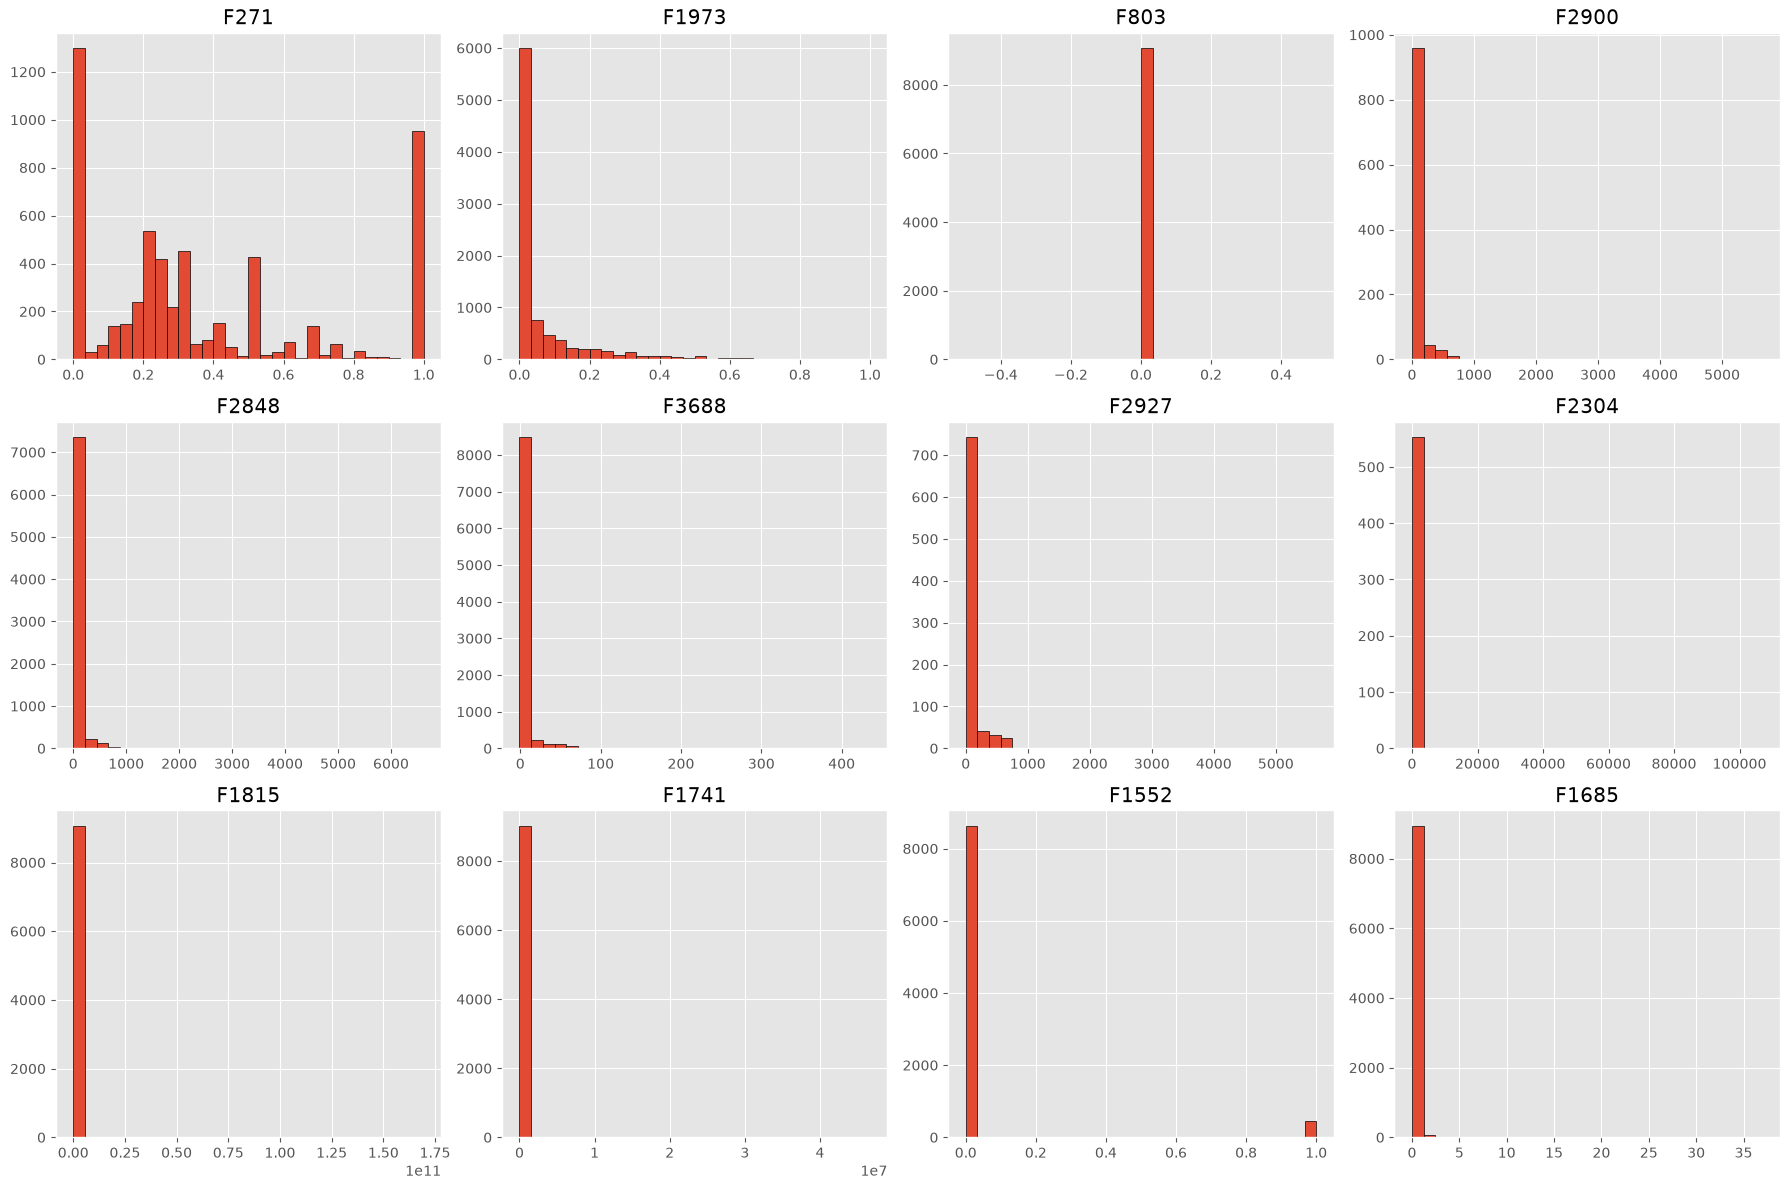

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(sample_features):

    axes[i].hist(
        df[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

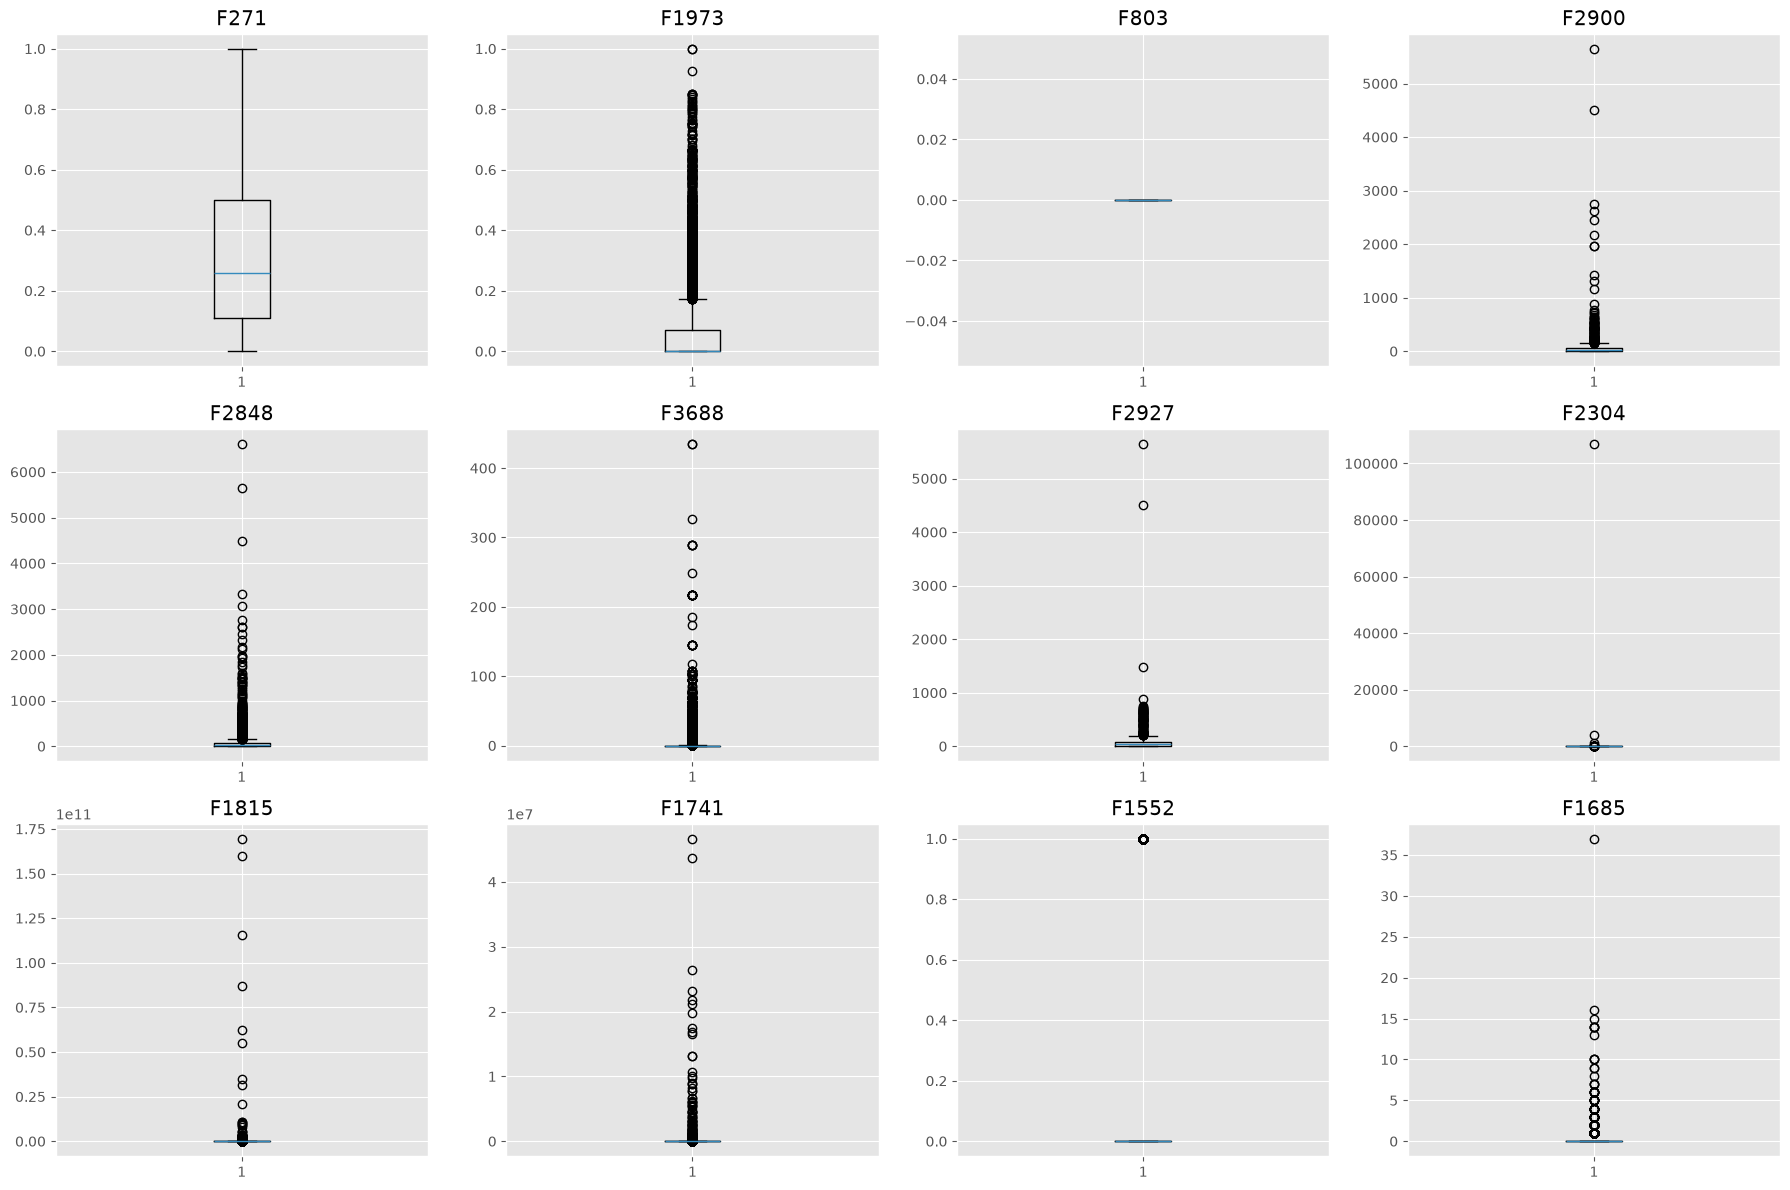

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(sample_features):

    axes[i].boxplot(df[col].dropna())

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [18]:
correlations = df.corr(numeric_only=True)[target]

correlations = correlations.drop(target)

correlations = correlations.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

correlations.head(30)

F3912    0.969066
F2506    0.184521
F2507    0.184521
F2409    0.157150
F2408    0.157150
F515     0.136986
F518     0.126906
F2578    0.118976
F82      0.116939
F81      0.116939
F83      0.116436
F84      0.116436
F255     0.113115
F2285    0.112599
F285     0.111709
F283     0.111696
F2779    0.109818
F253     0.109353
F287     0.105882
F286     0.105848
F267     0.105331
F78      0.098537
F77      0.098500
F2502   -0.098069
F2503   -0.097871
F2686    0.097861
F3908    0.097022
F258     0.095736
F388     0.094872
F389     0.094872
Name: F3924, dtype: float64

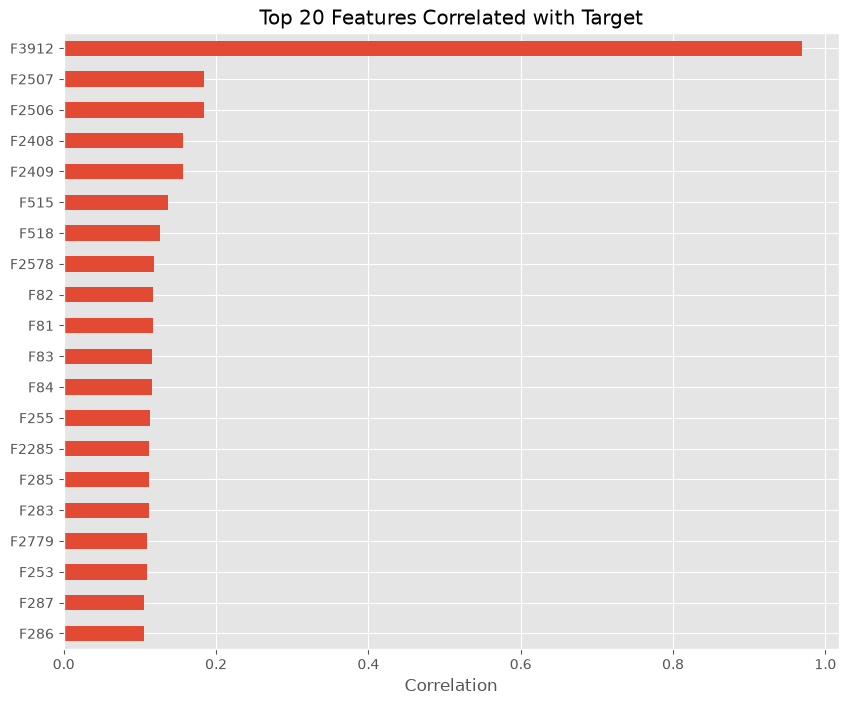

In [19]:
top_corr = correlations.head(20)

plt.figure(figsize=(10,8))

top_corr.sort_values().plot(kind="barh")

plt.title("Top 20 Features Correlated with Target")

plt.xlabel("Correlation")

plt.show()

In [20]:
df["F3912"].describe()

count    9082.000000
mean        0.009029
std         0.094596
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: F3912, dtype: float64

In [21]:
df[["F3912", target]].head(20)

,F3912,F3924
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [22]:
pd.crosstab(df["F3912"], df[target])

F3924,0,1
F3912,,
0,8998,2
1,3,79


## Leakage Investigation

Feature F3912 shows a correlation of 0.969 with the target.

Cross-tab analysis indicates:

• 79/81 fraud samples have F3912 = 1
• 8998/9001 normal samples have F3912 = 0

This strongly suggests potential target leakage.

Two versions of the model will be evaluated:

1. Including F3912
2. Excluding F3912

This helps verify whether the feature represents genuine predictive information or leaked target information.